<a href="https://colab.research.google.com/github/Shrutika2026/Sqrock-DataScience-Week2-StudentDashboard-Task1/blob/main/DataScience_Week2_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load and look at the first 5 rows
df = pd.read_csv('/content/archive.zip')
print(df.head())

# Check for missing values (Your Task 1 requirement)
print("\nMissing values per column:")
print(df.isnull().sum())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Missing values per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 1. Define Features (X) and Target (y)
# We use reading and writing scores to predict math scores
X = df[['reading score', 'writing score']]
y = df['math score']

# 2. Split the data into Training (80%) and Testing (20%)
# Training is for learning, Testing is for the final exam of the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully!")

Data split successfully!


In [ ]:
# 3. Initialize and Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions on the test set to see how it performed
y_pred = model.predict(X_test)

# 5. Evaluate the model
print(f"R2 Score (Accuracy): {r2_score(y_test, y_pred):.2f}")

R2 Score (Accuracy): 0.68


In [ ]:
# Save the model to a file
joblib.dump(model, 'student_model.pkl')
print("Model saved as student_model.pkl!")

Model saved as student_model.pkl!


/tmp/ipykernel_23392/3473703449.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='race/ethnicity', palette='viridis')


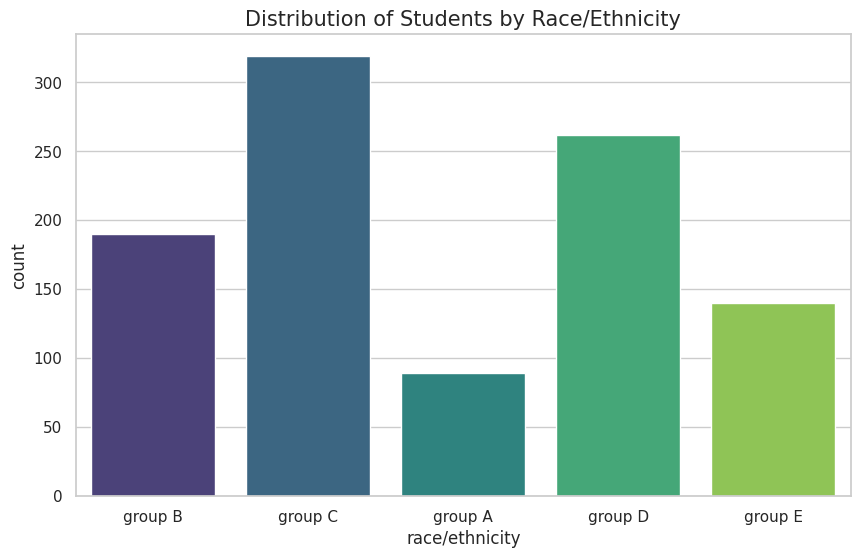

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('StudentsPerformance.csv')

# Set aesthetic style for the presentation
sns.set(style="whitegrid")

# Create a figure with multiple subplots or separate figures
# Here we will generate them as separate figures for clarity in your presentation

# --- 1. Bar Graph ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='race/ethnicity', palette='viridis')
plt.title('Distribution of Students by Race/Ethnicity', fontsize=15)
plt.show()


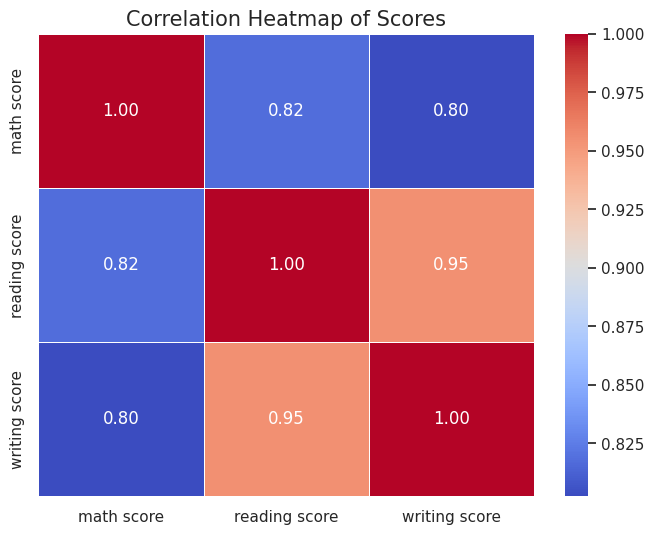

In [ ]:
# --- 2. Heatmap ---
plt.figure(figsize=(8, 6))
correlation = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Scores', fontsize=15)
plt.show()

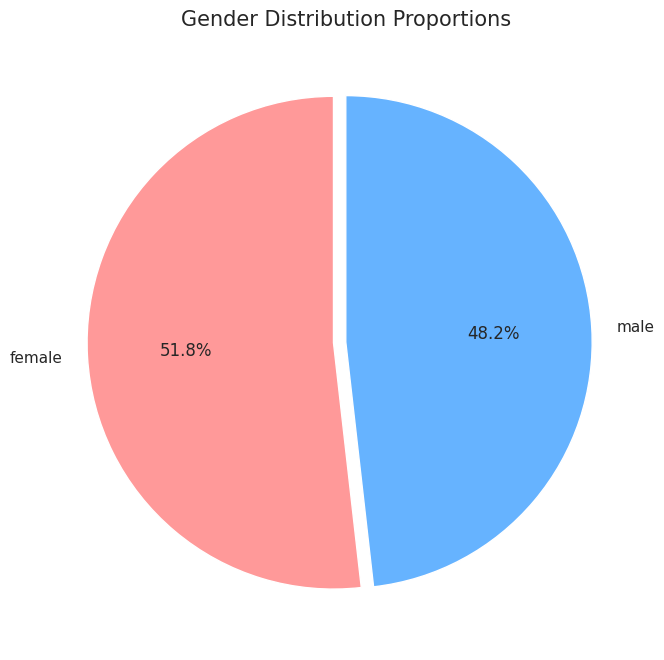

In [ ]:
# --- 3. Pie Chart ---
plt.figure(figsize=(8, 8))
df['gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
plt.title('Gender Distribution Proportions', fontsize=15)
plt.ylabel('')
plt.show()

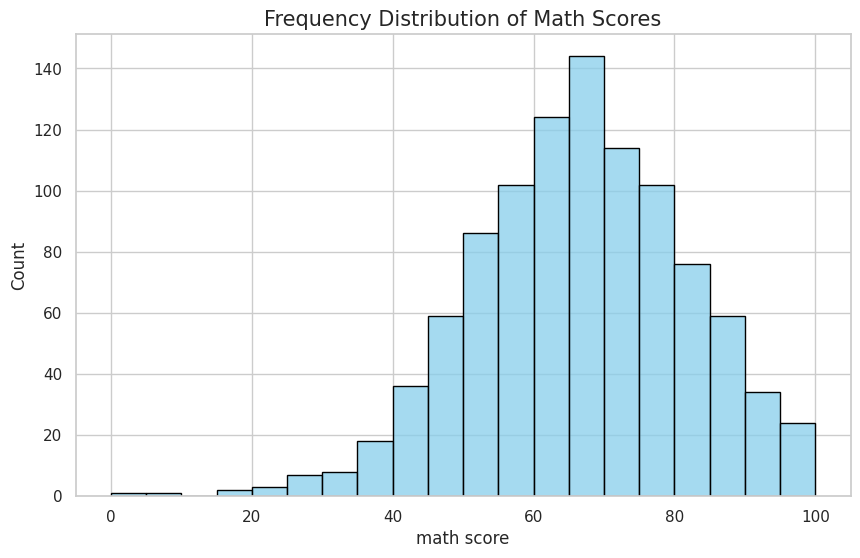

In [ ]:
# --- 4. Histogram ---
plt.figure(figsize=(10, 6))
sns.histplot(df['math score'], bins=20, kde=False, color='skyblue', edgecolor='black')
plt.title('Frequency Distribution of Math Scores', fontsize=15)
plt.show()

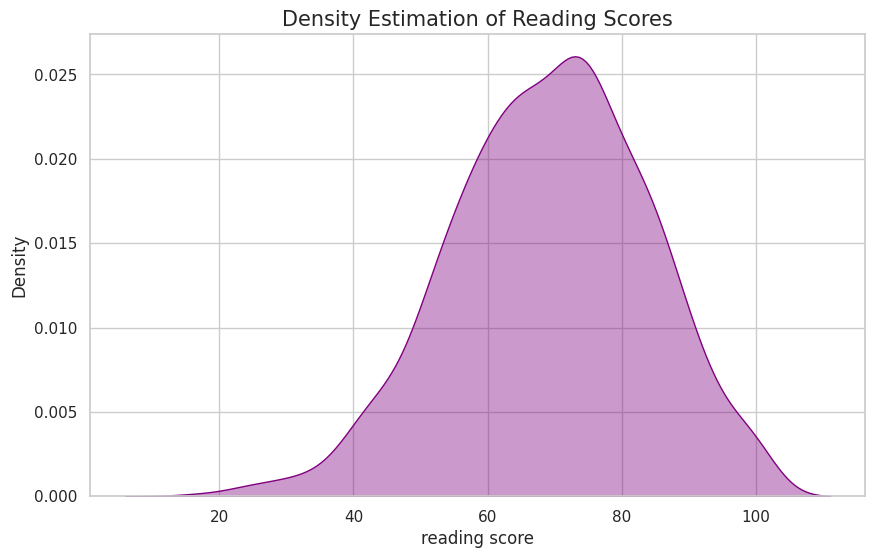

In [ ]:
# --- 5. Distplot (KDE) ---
plt.figure(figsize=(10, 6))
sns.kdeplot(df['reading score'], fill=True, color='purple', alpha=0.4)
plt.title('Density Estimation of Reading Scores', fontsize=15)
plt.show()

/tmp/ipykernel_23392/3547806308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='math score', data=df, palette='Set2')


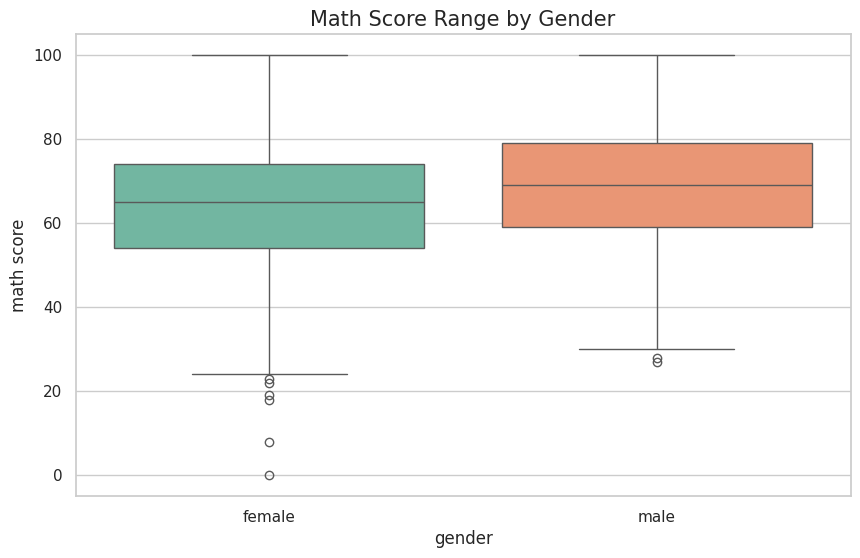

In [ ]:
# --- 6. Box Plot ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='math score', data=df, palette='Set2')
plt.title('Math Score Range by Gender', fontsize=15)
plt.show()

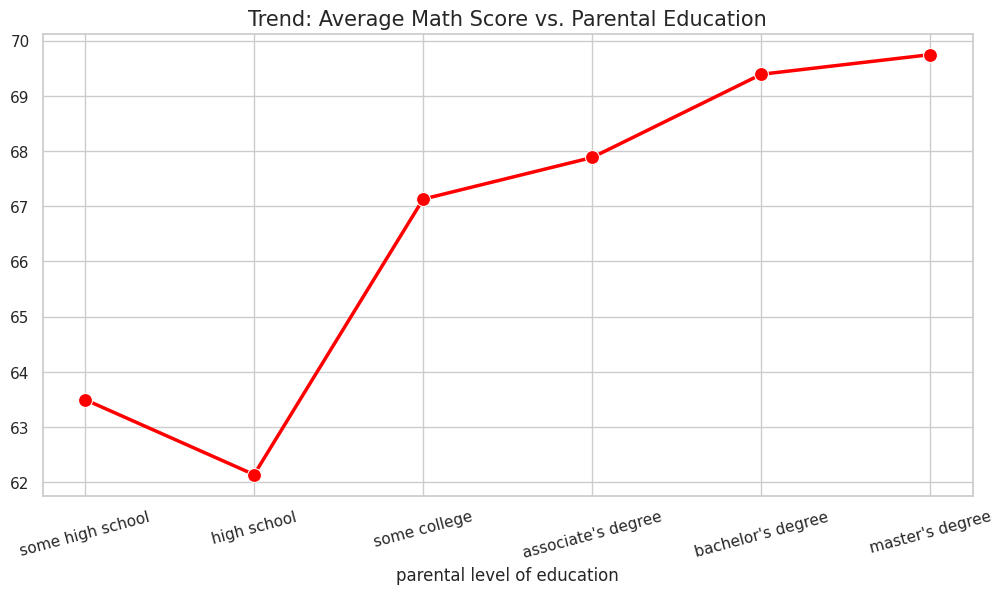

In [ ]:
# --- 7. Line Plot ---
# Calculating mean score per education level for a logical line trend
plt.figure(figsize=(12, 6))
edu_order = ["some high school", "high school", "some college", "associate's degree", "bachelor's degree", "master's degree"]
avg_math = df.groupby('parental level of education')['math score'].mean().reindex(edu_order)
sns.lineplot(x=avg_math.index, y=avg_math.values, marker='o', markersize=10, color='red', linewidth=2.5)
plt.title('Trend: Average Math Score vs. Parental Education', fontsize=15)
plt.xticks(rotation=15)
plt.show()

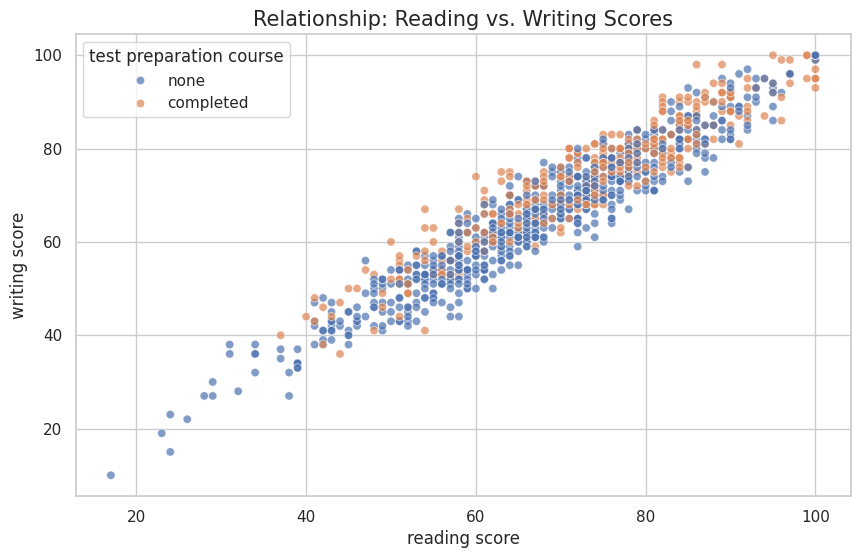

In [ ]:
# --- 8. Scatter Plot ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='reading score', y='writing score', data=df, hue='test preparation course', alpha=0.7)
plt.title('Relationship: Reading vs. Writing Scores', fontsize=15)
plt.show()

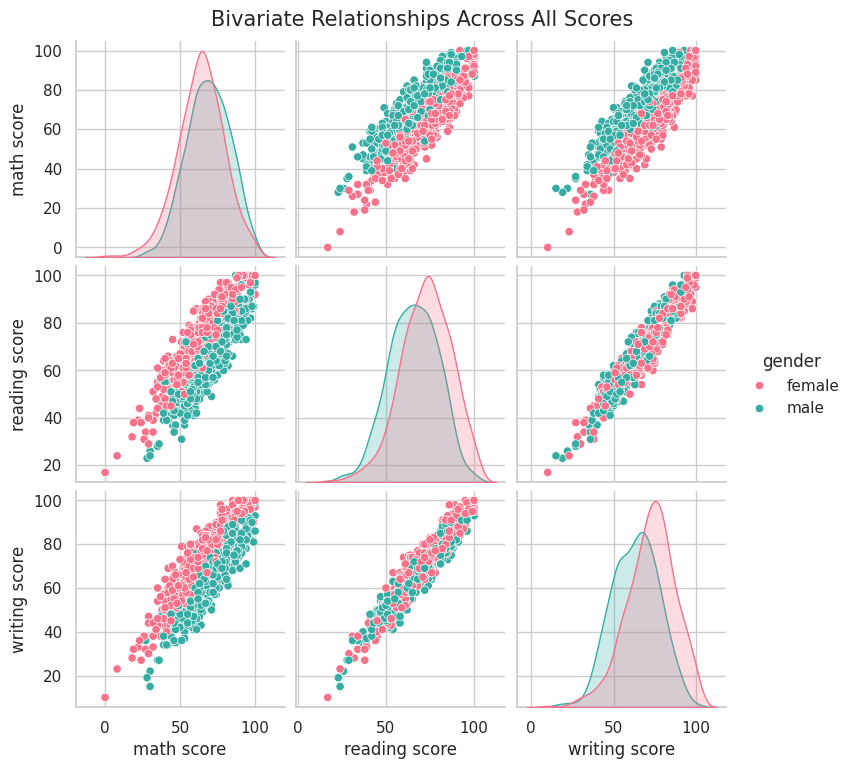

In [ ]:
# --- 9. Pair Plot ---
pair_plot = sns.pairplot(df, hue='gender', palette='husl', diag_kind='kde')
pair_plot.fig.suptitle('Bivariate Relationships Across All Scores', y=1.02, fontsize=15)
plt.show()